# TPS Over Time Plot

This notebook loads commit TPS data, node-side client receive-rate CSV samples, and leader PrePrepare process-rate CSV samples, then plots throughput over time and prints summary metrics for analysis.


In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linestyle": "--",
    "axes.facecolor": "#fcfcfd",
    "figure.facecolor": "white",
    "font.size": 12,
})

In [ ]:
import pandas as pd

df = pd.read_csv("logs/node_3_throughput.csv")
df["time"] = pd.to_datetime(df["time"])
df["gap_ms"] = df["time"].diff().dt.total_seconds() * 1000

max_idx = df["gap_ms"].idxmax()
before = df.loc[max_idx - 1]
after = df.loc[max_idx]

print(df["gap_ms"].describe(percentiles=[0.95, 0.99]))

print("\nMaximum gap:")
print(f"Gap:      {after['gap_ms']:.3f} ms")
print(f"From:     {before['time']}  (seq={before['seq']}, view={before['view']})")
print(f"To:       {after['time']}  (seq={after['seq']}, view={after['view']})")

count      59.000000
mean      941.673769
std        78.741954
min       905.917536
50%       928.565501
95%      1203.235161
99%      1240.183663
max      1258.449810
Name: gap_ms, dtype: float64

Maximum gap:
Gap:      1258.450 ms
From:     2026-09-06 21:54:02.429574140+00:00  (seq=13750, view=7)
To:       2026-09-06 21:54:03.688023950+00:00  (seq=14000, view=9)


,view,time,leader_id,executed_slots,elapsed_seconds,tput_measurement,seq,elapsed_from_first_sec
0,1,2026-09-07 18:23:41.802750493-06:00,1,497,1.828482,271.810188,500,0.000000
1,1,2026-09-07 18:23:42.739212881-06:00,1,747,2.764944,270.168195,750,0.936462
2,1,2026-09-07 18:23:43.642548611-06:00,1,997,3.668280,271.789505,1000,1.839798
3,1,2026-09-07 18:23:44.572140716-06:00,1,1247,4.597872,271.212417,1250,2.769390
4,1,2026-09-07 18:23:45.478929531-06:00,1,1497,5.504661,271.951352,1500,3.676179


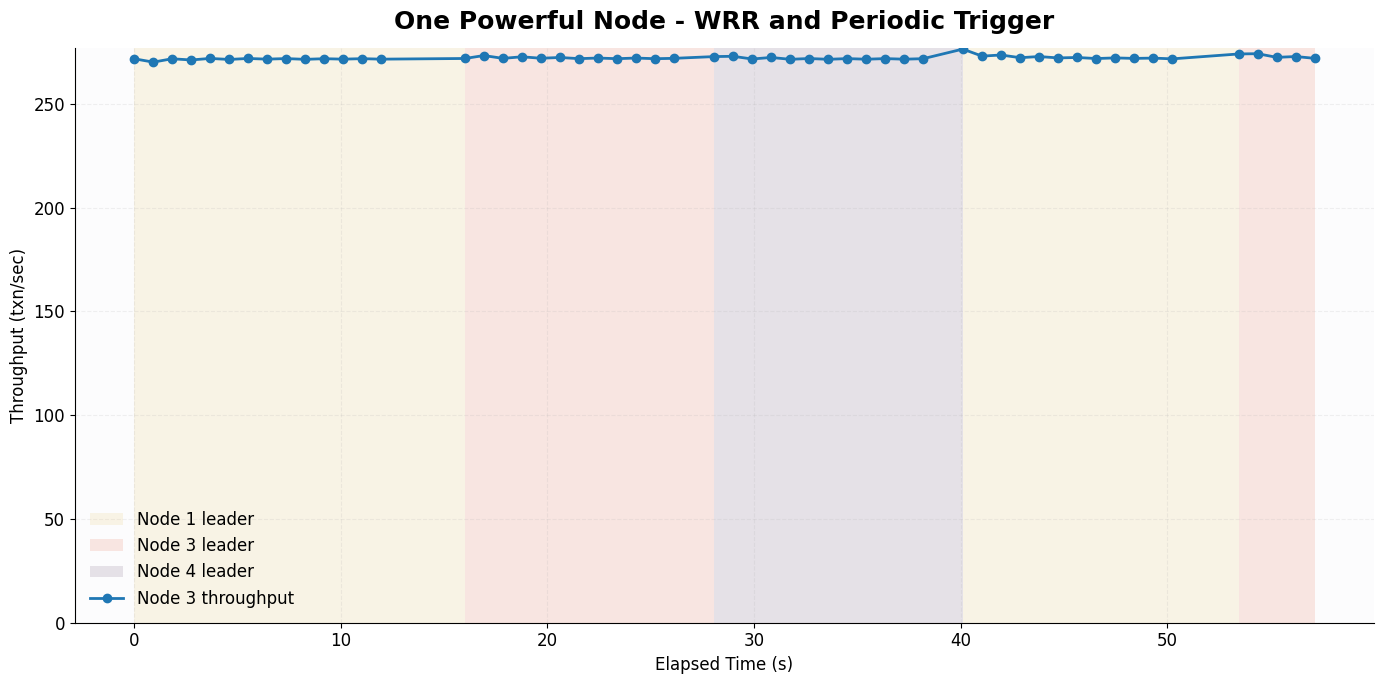

In [5]:
# Change this to pick which node throughput CSV to plot.
node_id = 3

view_start = 0

view_end = 30

throughput_csv_path = Path("logs") / f"node_{node_id}_throughput.csv"
assert throughput_csv_path.exists(), f"Missing file: {throughput_csv_path.resolve()}"

throughput_df = pd.read_csv(throughput_csv_path)
throughput_df["time"] = pd.to_datetime(throughput_df["time"])

throughput_df = throughput_df.sort_values(["time"]).reset_index(drop=True)

# Remove the first 3 seconds of measurements from each view.
throughput_df = throughput_df[throughput_df["elapsed_seconds"] >= 1].copy()
throughput_df = throughput_df.reset_index(drop=True)

# throughput_df = throughput_df[
#     throughput_df["view"].between(view_start, view_end)
# ].copy()
# high_mask = throughput_df["tput_measurement"] > 4500

# high_values = throughput_df.loc[high_mask, "tput_measurement"]

# if len(high_values) > 0:
#     high_min = high_values.min()
#     high_max = high_values.max()

#     if high_min == high_max:
#         throughput_df.loc[high_mask, "tput_measurement"] = 2100
#     else:
#         throughput_df.loc[high_mask, "tput_measurement"] = 4000



throughput_df["elapsed_from_first_sec"] = (
    throughput_df["time"] - throughput_df["time"].iloc[0]
).dt.total_seconds()

# throughput_df.to_csv(f"logs/node_{node_id}_throughput_cleaned.csv", index=False)

display(throughput_df.head())

fig, ax = plt.subplots(figsize=(14, 7))

leader_colors = {
    1: "#E9C46A",
    2: "#2A9D8F",
    3: "#E76F51",
    4: "#6D597A",
}
leader_change = throughput_df["leader_id"].ne(throughput_df["leader_id"].shift())
segment_id = leader_change.cumsum()
leader_segments = (
    throughput_df.groupby(segment_id)
    .agg(
        leader_id=("leader_id", "first"),
        start_sec=("elapsed_from_first_sec", "first"),
    )
    .reset_index(drop=True)
)
leader_segments["end_sec"] = leader_segments["start_sec"].shift(-1)
leader_segments.loc[leader_segments.index[-1], "end_sec"] = throughput_df[
    "elapsed_from_first_sec"
].iloc[-1]

seen_leaders = set()
for segment in leader_segments.itertuples(index=False):
    leader = int(segment.leader_id)
    label = f"Node {leader} leader" if leader not in seen_leaders else None
    ax.axvspan(
        segment.start_sec,
        segment.end_sec,
        color=leader_colors.get(leader, "#8D99AE"),
        alpha=0.16,
        label=label,
        linewidth=0,
    )
    seen_leaders.add(leader)

ax.plot(
    throughput_df["elapsed_from_first_sec"],
    throughput_df["tput_measurement"],
    marker="o",
    linewidth=2,
    label=f"Node {node_id} throughput",
)

ax.set_title(f"One Powerful Node - WRR and Periodic Trigger", fontsize=18, weight="bold", pad=14)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Throughput (txn/sec)")
ax.set_ylim(bottom=0)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()


In [3]:
json_path = Path("results/fixedrr_20260922_014036/report.json")
assert json_path.exists(), f"Missing file: {json_path.resolve()}"

with json_path.open() as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
# df = df[(df["average_tps"] >= 500) & (df["average_tps"] <= 3000)].copy()

df = df.sort_values("elapsed_sec").reset_index(drop=True)
# df = df[df["elapsed_sec"].between(18239, 27000, inclusive="both")].copy()
df["window_tps_smooth"] = df["window_tps"].rolling(window=90, min_periods=90).mean()

change_mask = df["committed_total"].ne(df["committed_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    plot_df = df.loc[:last_change_idx].copy()
else:
    plot_df = df.copy()

summary = {
    "samples": int(len(df)),
    "plot_samples": int(len(plot_df)),
    "final_committed": int(df["committed_total"].max()),
    "peak_window_tps": float(plot_df["window_tps"].max()),
    "peak_smoothed_tps": float(plot_df["window_tps_smooth"].max()),
    "final_average_tps": float(plot_df["average_tps"].iloc[-1]),
    "elapsed_sec": float(plot_df["elapsed_sec"].iloc[-1]),
}

pd.Series(summary)

samples              2.730010e+05
plot_samples         2.730010e+05
final_committed      8.263587e+07
peak_window_tps      2.203965e+04
peak_smoothed_tps    1.473333e+04
final_average_tps    3.026952e+03
elapsed_sec          2.730003e+04
dtype: float64

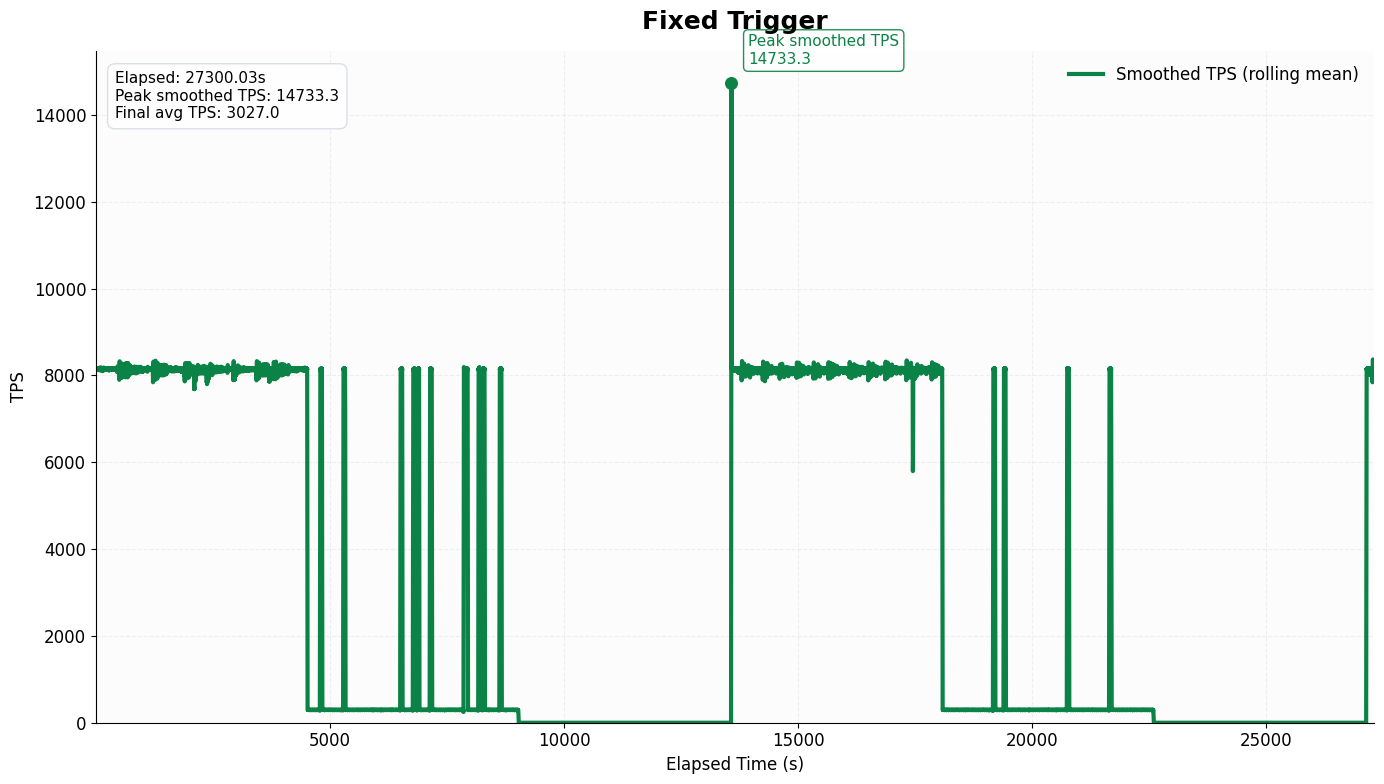

In [4]:
fig, ax1 = plt.subplots()

throughput_color = "#145DA0"
smooth_color = "#0C8346"

# ax1.plot(
#     plot_df["elapsed_sec"],
#     plot_df["window_tps"],
#     color=throughput_color,
#     linewidth=2.0,
#     alpha=0.35,
#     label="Window TPS",
# )
ax1.plot(
    plot_df["elapsed_sec"],
    plot_df["window_tps_smooth"],
    color=smooth_color,
    linewidth=3.0,
    label="Smoothed TPS (rolling mean)",
)

peak_idx = plot_df["window_tps_smooth"].idxmax()
peak_x = plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = plot_df.loc[peak_idx, "window_tps_smooth"]
ax1.scatter([peak_x], [peak_y], color=smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed TPS\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=smooth_color, alpha=0.9),
)

ax1.set_title("Fixed Trigger", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("TPS")

ax1.set_xlim(plot_df["elapsed_sec"].min(), plot_df["elapsed_sec"].max())

ax1.set_ylim(bottom=0)

summary_text = (
    f"Elapsed: {summary['elapsed_sec']:.2f}s\n"
    
    f"Peak smoothed TPS: {summary['peak_smoothed_tps']:.1f}\n"
    f"Final avg TPS: {summary['final_average_tps']:.1f}"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

ax1.legend(loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


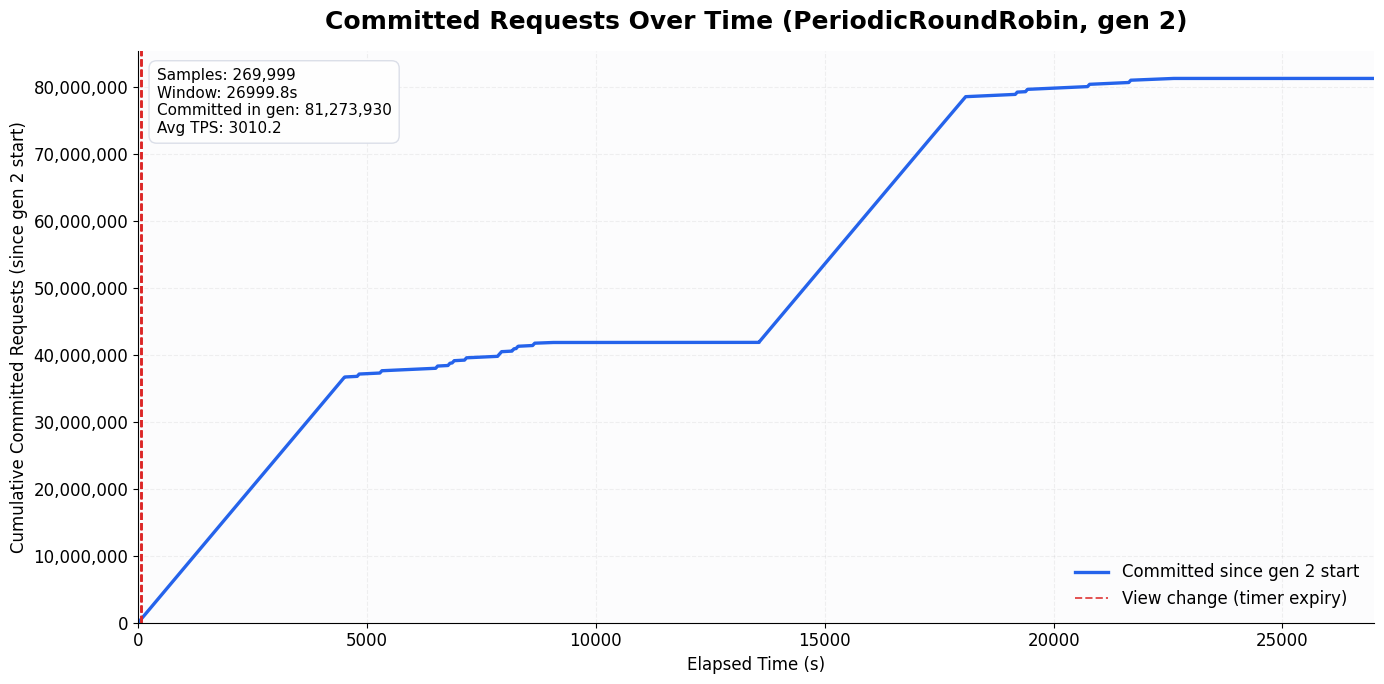

In [5]:
gen_start, gen_end = 0, 27000
# view-change points in elapsed_sec (replica progress timers expiring, from node logs)
view_change_marks = [56.8, 67.6, 78.0, 88.4]

commit_df = df[df["elapsed_sec"].between(gen_start, gen_end)].copy()
commit_df["committed_in_gen"] = commit_df["committed_total"] - commit_df["committed_total"].iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    commit_df["elapsed_sec"],
    commit_df["committed_in_gen"],
    color="#2563EB",
    linewidth=2.4,
    label="Committed since gen 2 start",
)
for i, t in enumerate(view_change_marks):
    ax.axvline(t, color="#DC2626", linestyle="--", linewidth=1.4, alpha=0.8,
               label="View change (timer expiry)" if i == 0 else None)

ax.set_title("Committed Requests Over Time (PeriodicRoundRobin, gen 2)", fontsize=18, weight="bold", pad=16)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests (since gen 2 start)")
ax.set_xlim(gen_start, gen_end)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

total = int(commit_df["committed_in_gen"].iloc[-1])
duration = commit_df["elapsed_sec"].iloc[-1] - commit_df["elapsed_sec"].iloc[0]
ax.text(
    0.015,
    0.97,
    f"Samples: {len(commit_df):,}\n"
    f"Window: {duration:.1f}s\n"
    f"Committed in gen: {total:,}\n"
    f"Avg TPS: {total / duration:.1f}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.show()


,epochs,scenario,start,end,committed,avg_tps
0,1-100,Healthy,0.0,4535.0,36827316.8,8120.7
1,101-200,ProposalDelay,4535.0,9076.1,29773254.2,6556.4
2,201-300,NetworkDelay,9076.1,13652.2,1493806.0,326.4
3,301-400,Healthy,13652.2,18193.6,36953159.5,8137.0
4,401-500,ProposalDelay,18193.6,22735.0,34171973.5,7524.4
5,501-600,NetworkDelay,22735.0,27300.0,2307877.0,505.6


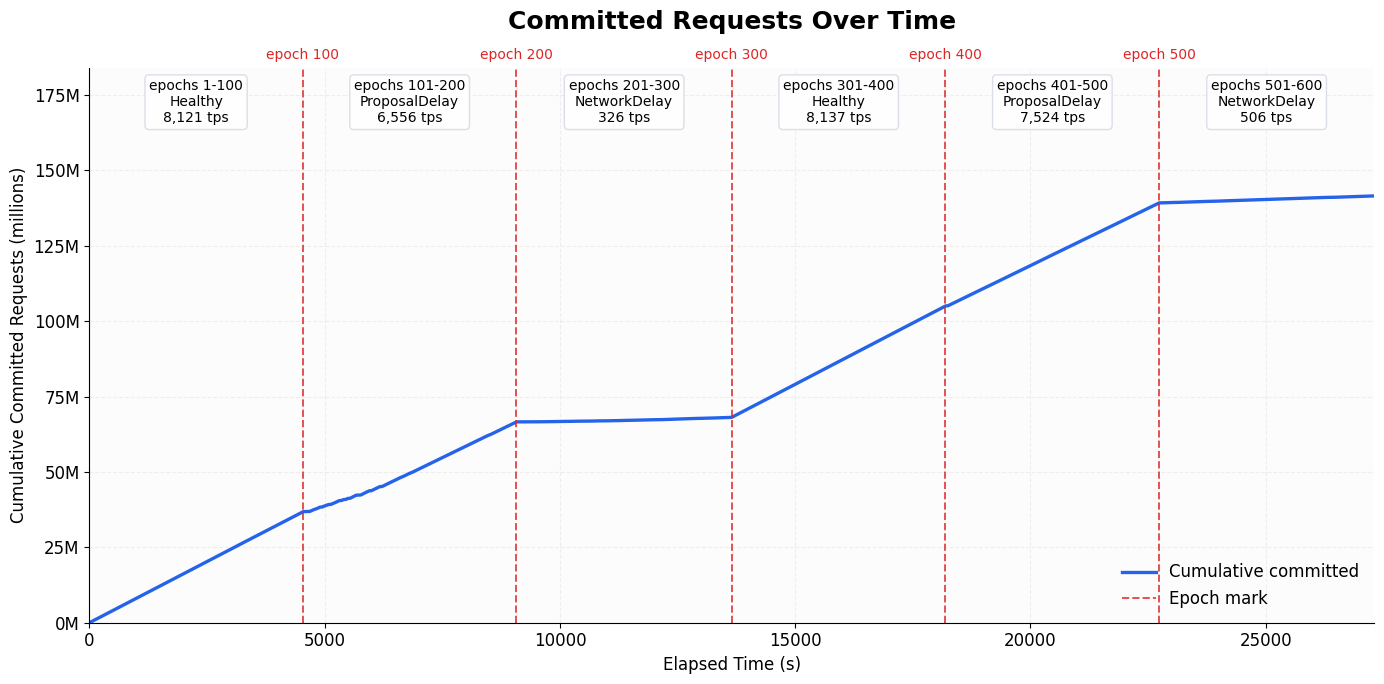

In [49]:
# Cumulative committed requests with epoch marks and per-scenario window average
# Epoch marks come from the "scenario switch gen=N" lines in node_1.log (UTC).
scenario_switches = [
    (100, "2026-09-20 02:32:49.208910"),
    (200, "2026-09-20 03:48:30.282941"),
    (300, "2026-09-20 05:04:46.391492"),
    (400, "2026-09-20 06:20:27.785521"),
    (500, "2026-09-20 07:36:09.262274"),
]
scenario_names = ["Healthy", "ProposalDelay", "NetworkDelay", "Healthy", "ProposalDelay", "NetworkDelay"]

# report.json elapsed_sec = 0 at (first sample time - first elapsed_sec)
run_start = pd.Timestamp(df["timestamp_unix_nano"].iloc[0], unit="ns") - pd.Timedelta(seconds=df["elapsed_sec"].iloc[0])
epoch_marks = [(ep, (pd.Timestamp(ts) - run_start.tz_localize(None)).total_seconds()) for ep, ts in scenario_switches]

cum_df = df[df["committed_total"] > 0].drop_duplicates("elapsed_sec")
end_sec = float(cum_df["elapsed_sec"].iloc[-1])
edges = [0.0] + [t for _, t in epoch_marks] + [end_sec]
epoch_labels = [f"{a}-{b}" for a, b in zip([1] + [e + 1 for e, _ in epoch_marks], [e for e, _ in epoch_marks] + [600])]

def committed_at(t):
    return float(np.interp(t, cum_df["elapsed_sec"], cum_df["committed_total"]))

scenario_stats = []
for i, (t0, t1) in enumerate(zip(edges[:-1], edges[1:])):
    c0, c1 = committed_at(t0), committed_at(t1)
    scenario_stats.append(dict(epochs=epoch_labels[i], scenario=scenario_names[i], start=t0, end=t1,
                               committed=c1 - c0, avg_tps=(c1 - c0) / (t1 - t0)))
display(pd.DataFrame(scenario_stats).round(1))

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(cum_df["elapsed_sec"], cum_df["committed_total"], color="#2563EB", linewidth=2.4,
        label="Cumulative committed")

for i, (ep, t) in enumerate(epoch_marks):
    ax.axvline(t, color="#DC2626", linestyle="--", linewidth=1.4, alpha=0.8,
               label="Epoch mark" if i == 0 else None)
    ax.text(t, 1.01, f"epoch {ep}", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontsize=10, color="#DC2626")

for s in scenario_stats:
    mid = (s["start"] + s["end"]) / 2
    ax.annotate(
        f"epochs {s['epochs']}\n{s['scenario']}\n{s['avg_tps']:,.0f} tps",
        xy=(mid, 0.98), xycoords=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d9dde7", alpha=0.95),
    )

ax.set_title("Committed Requests Over Time", fontsize=18, weight="bold", pad=28)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests (millions)")
ax.set_xlim(0, end_sec)
ax.set_ylim(0, cum_df["committed_total"].max() * 1.3)  # headroom for the labels
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value / 1e6:g}M"))
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.show()


,epochs,scenario,start,end,committed,avg_tps
0,1-100,Healthy,0.0,4510.4,36689528.1,8134.4
1,101-200,ProposalDelay,4510.4,9020.6,5155941.9,1143.2
2,201-300,NetworkDelay,9020.6,13565.4,197.2,0.0
3,301-400,Healthy,13565.4,18075.8,36703595.3,8137.4
4,401-500,ProposalDelay,18075.8,22586.1,2724667.5,604.1
5,501-600,NetworkDelay,22586.1,27132.3,0.0,0.0
6,601-700,Healthy,27132.3,27300.0,1361461.0,8116.1


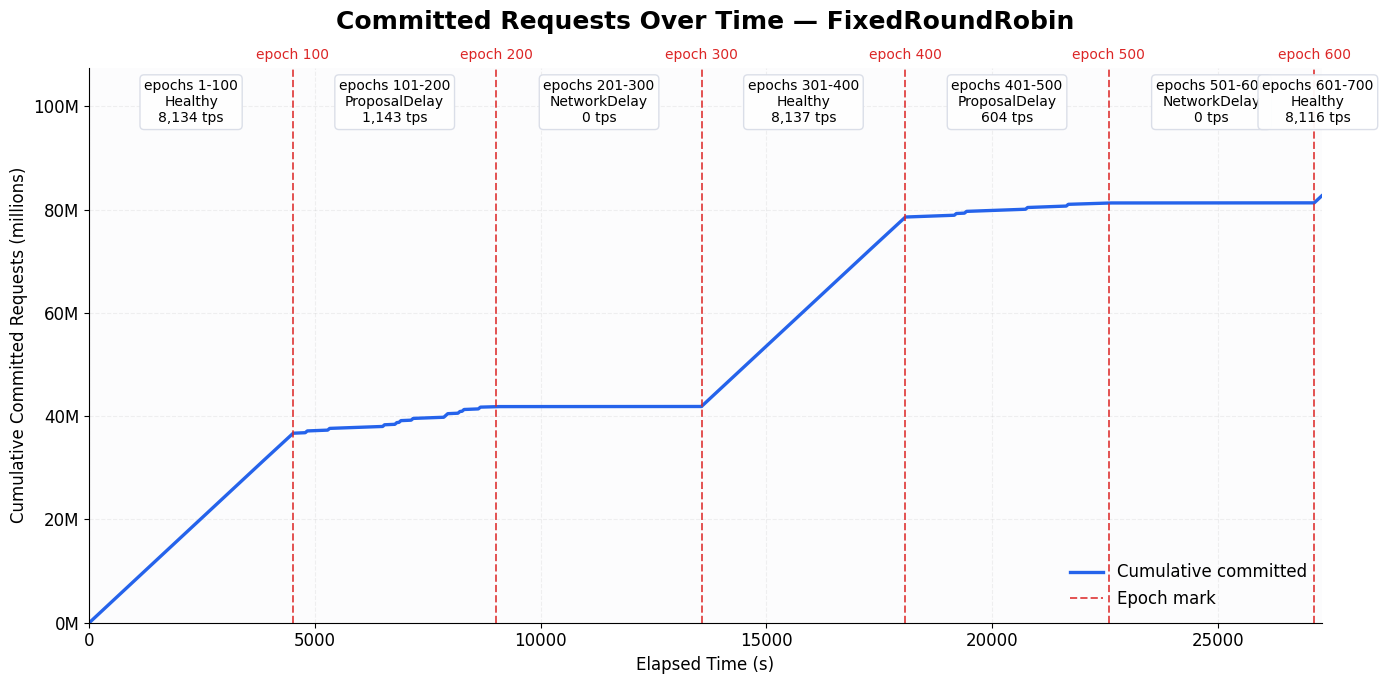

In [6]:
# Cumulative committed requests with epoch marks and per-scenario window average — FixedRoundRobin (fixedrr_20260922_014036)
# Epoch marks come from the "scenario switch gen=N" lines in node_1.log (UTC).
json_path = Path("results/fixedrr_20260922_014036/report.json")
assert json_path.exists(), f"Missing file: {json_path.resolve()}"
with json_path.open() as f:
    raw_fixed = json.load(f)
df_fixed = pd.DataFrame(raw_fixed).sort_values("elapsed_sec").reset_index(drop=True)

scenario_switches_fixed = [
    (100, "2026-09-22 02:55:54.068521"),
    (200, "2026-09-22 04:11:04.307229"),
    (300, "2026-09-22 05:26:49.055385"),
    (400, "2026-09-22 06:41:59.511526"),
    (500, "2026-09-22 07:57:09.814760"),
    (600, "2026-09-22 09:12:55.946807"),
]
scenario_names_fixed = ["Healthy", "ProposalDelay", "NetworkDelay", "Healthy", "ProposalDelay", "NetworkDelay", "Healthy"]

# report.json elapsed_sec = 0 at (first sample time - first elapsed_sec)
run_start_fixed = pd.Timestamp(df_fixed["timestamp_unix_nano"].iloc[0], unit="ns") - pd.Timedelta(seconds=df_fixed["elapsed_sec"].iloc[0])
epoch_marks_fixed = [(ep, (pd.Timestamp(ts) - run_start_fixed.tz_localize(None)).total_seconds()) for ep, ts in scenario_switches_fixed]

cum_df_fixed = df_fixed[df_fixed["committed_total"] > 0].drop_duplicates("elapsed_sec")
end_sec_fixed = float(cum_df_fixed["elapsed_sec"].iloc[-1])
edges_fixed = [0.0] + [t for _, t in epoch_marks_fixed] + [end_sec_fixed]
epoch_labels_fixed = [f"{a}-{b}" for a, b in zip([1] + [e + 1 for e, _ in epoch_marks_fixed], [e for e, _ in epoch_marks_fixed] + [700])]

def committed_at_fixed(t):
    return float(np.interp(t, cum_df_fixed["elapsed_sec"], cum_df_fixed["committed_total"]))

scenario_stats_fixed = []
for i, (t0, t1) in enumerate(zip(edges_fixed[:-1], edges_fixed[1:])):
    c0, c1 = committed_at_fixed(t0), committed_at_fixed(t1)
    scenario_stats_fixed.append(dict(epochs=epoch_labels_fixed[i], scenario=scenario_names_fixed[i], start=t0, end=t1,
                               committed=c1 - c0, avg_tps=(c1 - c0) / (t1 - t0)))
display(pd.DataFrame(scenario_stats_fixed).round(1))

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(cum_df_fixed["elapsed_sec"], cum_df_fixed["committed_total"], color="#2563EB", linewidth=2.4,
        label="Cumulative committed")

for i, (ep, t) in enumerate(epoch_marks_fixed):
    ax.axvline(t, color="#DC2626", linestyle="--", linewidth=1.4, alpha=0.8,
               label="Epoch mark" if i == 0 else None)
    ax.text(t, 1.01, f"epoch {ep}", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontsize=10, color="#DC2626")

for s in scenario_stats_fixed:
    mid = (s["start"] + s["end"]) / 2
    ax.annotate(
        f"epochs {s['epochs']}\n{s['scenario']}\n{s['avg_tps']:,.0f} tps",
        xy=(mid, 0.98), xycoords=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d9dde7", alpha=0.95),
    )

ax.set_title("Committed Requests Over Time — FixedRoundRobin", fontsize=18, weight="bold", pad=28)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests (millions)")
ax.set_xlim(0, end_sec_fixed)
ax.set_ylim(0, cum_df_fixed["committed_total"].max() * 1.3)  # headroom for the labels
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value / 1e6:g}M"))
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.show()

,epochs,scenario,start,end,committed,avg_tps
0,1-100,Healthy,0.0,4510.4,36136438.5,8011.8
1,101-200,ProposalDelay,4510.4,9020.8,33752460.5,7483.3
2,201-300,NetworkDelay,9020.8,13568.4,1740.0,0.4
3,301-400,Healthy,13568.4,18078.8,36171250.7,8019.5
4,401-500,ProposalDelay,18078.8,22589.2,33731361.0,7478.7
5,501-600,NetworkDelay,22589.2,27134.5,478.2,0.1
6,601-700,Healthy,27134.5,27300.0,1326480.0,8011.2


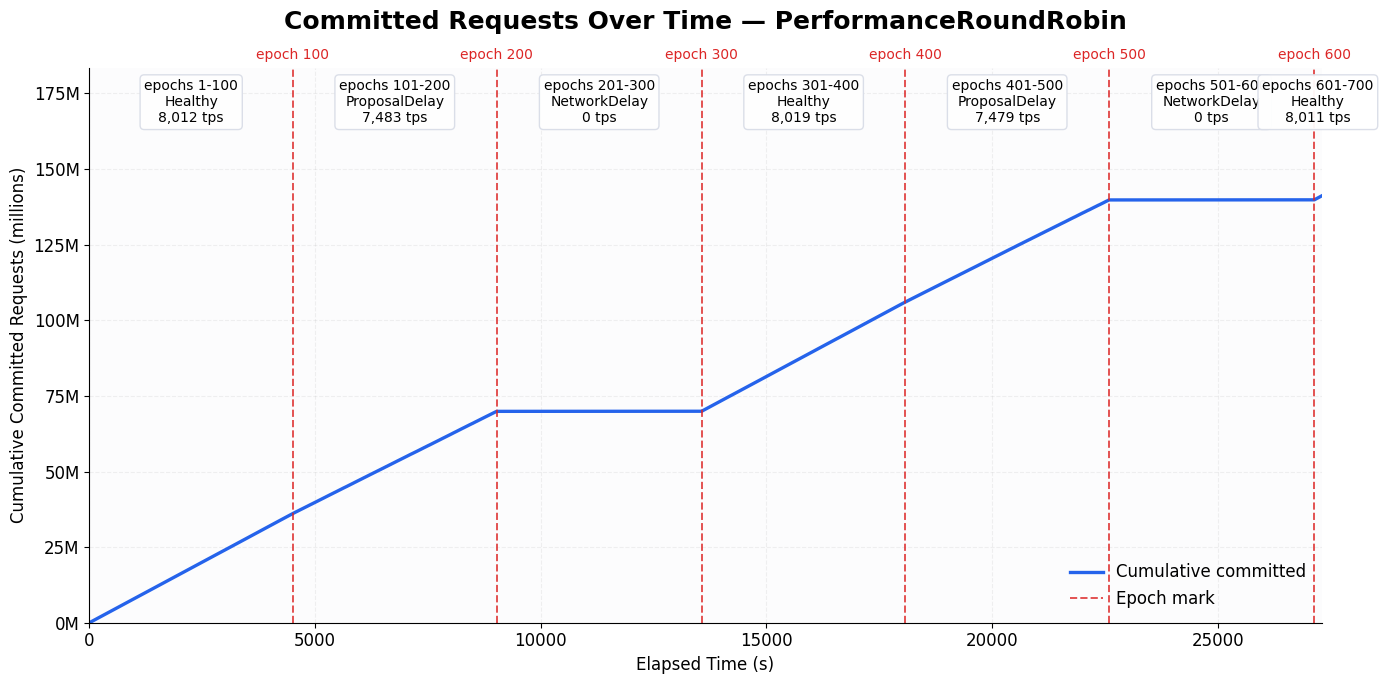

In [7]:
# Cumulative committed requests with epoch marks and per-scenario window average — PerformanceRoundRobin (perfrr_20260922_014143)
# Epoch marks come from the "scenario switch gen=N" lines in node_1.log (UTC).
json_path = Path("results/perfrr_20260922_014143/report.json")
assert json_path.exists(), f"Missing file: {json_path.resolve()}"
with json_path.open() as f:
    raw_perf = json.load(f)
df_perf = pd.DataFrame(raw_perf).sort_values("elapsed_sec").reset_index(drop=True)

scenario_switches_perf = [
    (100, "2026-09-22 02:57:01.140487"),
    (200, "2026-09-22 04:12:11.504616"),
    (300, "2026-09-22 05:27:59.168365"),
    (400, "2026-09-22 06:43:09.583775"),
    (500, "2026-09-22 07:58:19.934677"),
    (600, "2026-09-22 09:14:05.210924"),
]
scenario_names_perf = ["Healthy", "ProposalDelay", "NetworkDelay", "Healthy", "ProposalDelay", "NetworkDelay", "Healthy"]

# report.json elapsed_sec = 0 at (first sample time - first elapsed_sec)
run_start_perf = pd.Timestamp(df_perf["timestamp_unix_nano"].iloc[0], unit="ns") - pd.Timedelta(seconds=df_perf["elapsed_sec"].iloc[0])
epoch_marks_perf = [(ep, (pd.Timestamp(ts) - run_start_perf.tz_localize(None)).total_seconds()) for ep, ts in scenario_switches_perf]

cum_df_perf = df_perf[df_perf["committed_total"] > 0].drop_duplicates("elapsed_sec")
end_sec_perf = float(cum_df_perf["elapsed_sec"].iloc[-1])
edges_perf = [0.0] + [t for _, t in epoch_marks_perf] + [end_sec_perf]
epoch_labels_perf = [f"{a}-{b}" for a, b in zip([1] + [e + 1 for e, _ in epoch_marks_perf], [e for e, _ in epoch_marks_perf] + [700])]

def committed_at_perf(t):
    return float(np.interp(t, cum_df_perf["elapsed_sec"], cum_df_perf["committed_total"]))

scenario_stats_perf = []
for i, (t0, t1) in enumerate(zip(edges_perf[:-1], edges_perf[1:])):
    c0, c1 = committed_at_perf(t0), committed_at_perf(t1)
    scenario_stats_perf.append(dict(epochs=epoch_labels_perf[i], scenario=scenario_names_perf[i], start=t0, end=t1,
                               committed=c1 - c0, avg_tps=(c1 - c0) / (t1 - t0)))
display(pd.DataFrame(scenario_stats_perf).round(1))

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(cum_df_perf["elapsed_sec"], cum_df_perf["committed_total"], color="#2563EB", linewidth=2.4,
        label="Cumulative committed")

for i, (ep, t) in enumerate(epoch_marks_perf):
    ax.axvline(t, color="#DC2626", linestyle="--", linewidth=1.4, alpha=0.8,
               label="Epoch mark" if i == 0 else None)
    ax.text(t, 1.01, f"epoch {ep}", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontsize=10, color="#DC2626")

for s in scenario_stats_perf:
    mid = (s["start"] + s["end"]) / 2
    ax.annotate(
        f"epochs {s['epochs']}\n{s['scenario']}\n{s['avg_tps']:,.0f} tps",
        xy=(mid, 0.98), xycoords=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d9dde7", alpha=0.95),
    )

ax.set_title("Committed Requests Over Time — PerformanceRoundRobin", fontsize=18, weight="bold", pad=28)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests (millions)")
ax.set_xlim(0, end_sec_perf)
ax.set_ylim(0, cum_df_perf["committed_total"].max() * 1.3)  # headroom for the labels
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value / 1e6:g}M"))
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.show()

,epochs,scenario,start,end,committed,avg_tps
0,1-100,Healthy,0.0,4510.4,36212864.1,8028.8
1,101-200,ProposalDelay,4510.4,9020.8,24653955.9,5466.1
2,201-300,NetworkDelay,9020.8,13564.9,2401290.0,528.4
3,301-400,Healthy,13564.9,18075.2,36254118.1,8038.0
4,401-500,ProposalDelay,18075.2,22585.5,24677831.9,5471.4
5,501-600,NetworkDelay,22585.5,27130.5,2400976.7,528.3
6,601-700,Healthy,27130.5,27300.1,1384603.3,8167.6


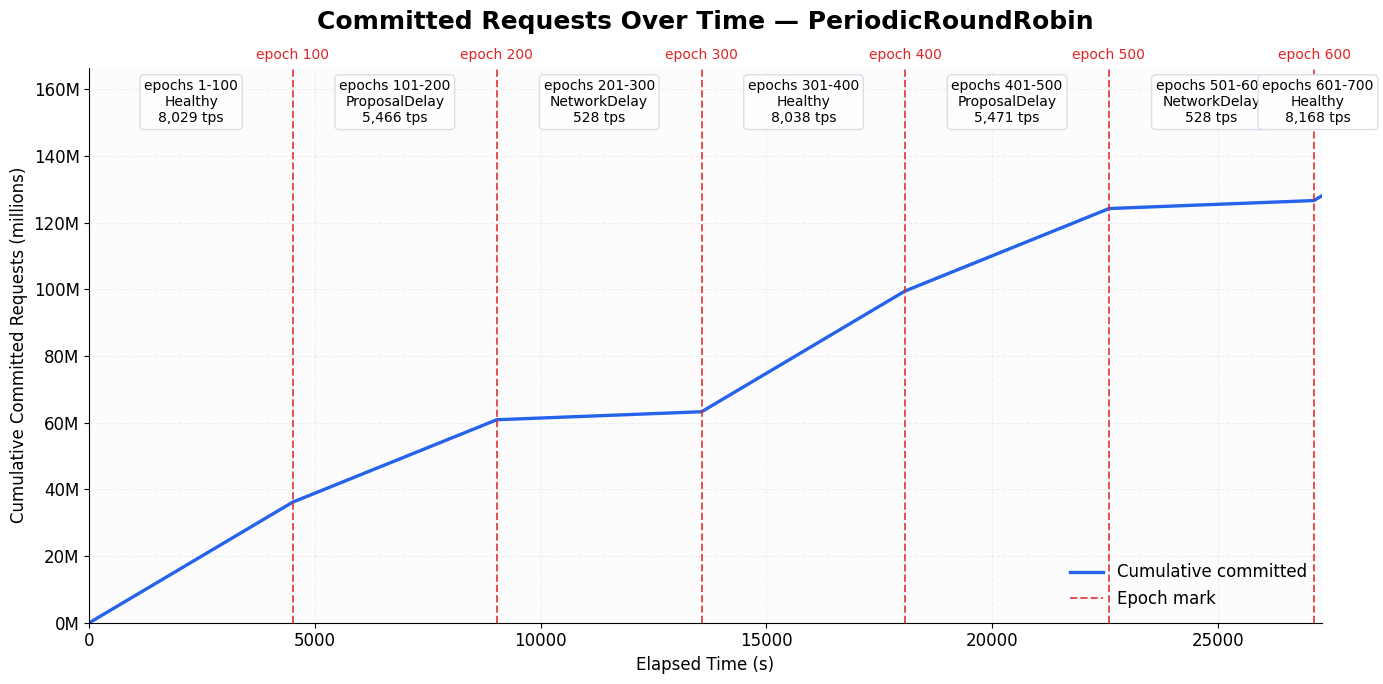

In [8]:
# Cumulative committed requests with epoch marks and per-scenario window average — PeriodicRoundRobin (periodicrr_20260922_014117)
# Epoch marks come from the "scenario switch gen=N" lines in node_1.log (UTC).
json_path = Path("results/periodicrr_20260922_014117/report.json")
assert json_path.exists(), f"Missing file: {json_path.resolve()}"
with json_path.open() as f:
    raw_periodic = json.load(f)
df_periodic = pd.DataFrame(raw_periodic).sort_values("elapsed_sec").reset_index(drop=True)

scenario_switches_periodic = [
    (100, "2026-09-22 02:56:35.414048"),
    (200, "2026-09-22 04:11:45.775652"),
    (300, "2026-09-22 05:27:29.884487"),
    (400, "2026-09-22 06:42:40.203517"),
    (500, "2026-09-22 07:57:50.547298"),
    (600, "2026-09-22 09:13:35.551659"),
]
scenario_names_periodic = ["Healthy", "ProposalDelay", "NetworkDelay", "Healthy", "ProposalDelay", "NetworkDelay", "Healthy"]

# report.json elapsed_sec = 0 at (first sample time - first elapsed_sec)
run_start_periodic = pd.Timestamp(df_periodic["timestamp_unix_nano"].iloc[0], unit="ns") - pd.Timedelta(seconds=df_periodic["elapsed_sec"].iloc[0])
epoch_marks_periodic = [(ep, (pd.Timestamp(ts) - run_start_periodic.tz_localize(None)).total_seconds()) for ep, ts in scenario_switches_periodic]

cum_df_periodic = df_periodic[df_periodic["committed_total"] > 0].drop_duplicates("elapsed_sec")
end_sec_periodic = float(cum_df_periodic["elapsed_sec"].iloc[-1])
edges_periodic = [0.0] + [t for _, t in epoch_marks_periodic] + [end_sec_periodic]
epoch_labels_periodic = [f"{a}-{b}" for a, b in zip([1] + [e + 1 for e, _ in epoch_marks_periodic], [e for e, _ in epoch_marks_periodic] + [700])]

def committed_at_periodic(t):
    return float(np.interp(t, cum_df_periodic["elapsed_sec"], cum_df_periodic["committed_total"]))

scenario_stats_periodic = []
for i, (t0, t1) in enumerate(zip(edges_periodic[:-1], edges_periodic[1:])):
    c0, c1 = committed_at_periodic(t0), committed_at_periodic(t1)
    scenario_stats_periodic.append(dict(epochs=epoch_labels_periodic[i], scenario=scenario_names_periodic[i], start=t0, end=t1,
                               committed=c1 - c0, avg_tps=(c1 - c0) / (t1 - t0)))
display(pd.DataFrame(scenario_stats_periodic).round(1))

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(cum_df_periodic["elapsed_sec"], cum_df_periodic["committed_total"], color="#2563EB", linewidth=2.4,
        label="Cumulative committed")

for i, (ep, t) in enumerate(epoch_marks_periodic):
    ax.axvline(t, color="#DC2626", linestyle="--", linewidth=1.4, alpha=0.8,
               label="Epoch mark" if i == 0 else None)
    ax.text(t, 1.01, f"epoch {ep}", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontsize=10, color="#DC2626")

for s in scenario_stats_periodic:
    mid = (s["start"] + s["end"]) / 2
    ax.annotate(
        f"epochs {s['epochs']}\n{s['scenario']}\n{s['avg_tps']:,.0f} tps",
        xy=(mid, 0.98), xycoords=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d9dde7", alpha=0.95),
    )

ax.set_title("Committed Requests Over Time — PeriodicRoundRobin", fontsize=18, weight="bold", pad=28)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests (millions)")
ax.set_xlim(0, end_sec_periodic)
ax.set_ylim(0, cum_df_periodic["committed_total"].max() * 1.3)  # headroom for the labels
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value / 1e6:g}M"))
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.show()

,epochs,scenario,start,end,committed,avg_tps
0,1-100,Healthy,0.0,4510.5,35975331.5,7975.9
1,101-200,ProposalDelay,4510.5,9020.8,26920377.0,5968.6
2,201-300,NetworkDelay,9020.8,13569.5,2291619.5,503.8
3,301-400,Healthy,13569.5,18079.8,35999158.5,7981.5
4,401-500,ProposalDelay,18079.8,22590.1,26102803.1,5787.4
5,501-600,NetworkDelay,22590.1,27139.6,2287458.4,502.8
6,601-700,Healthy,27139.6,27300.1,1278540.0,7967.0


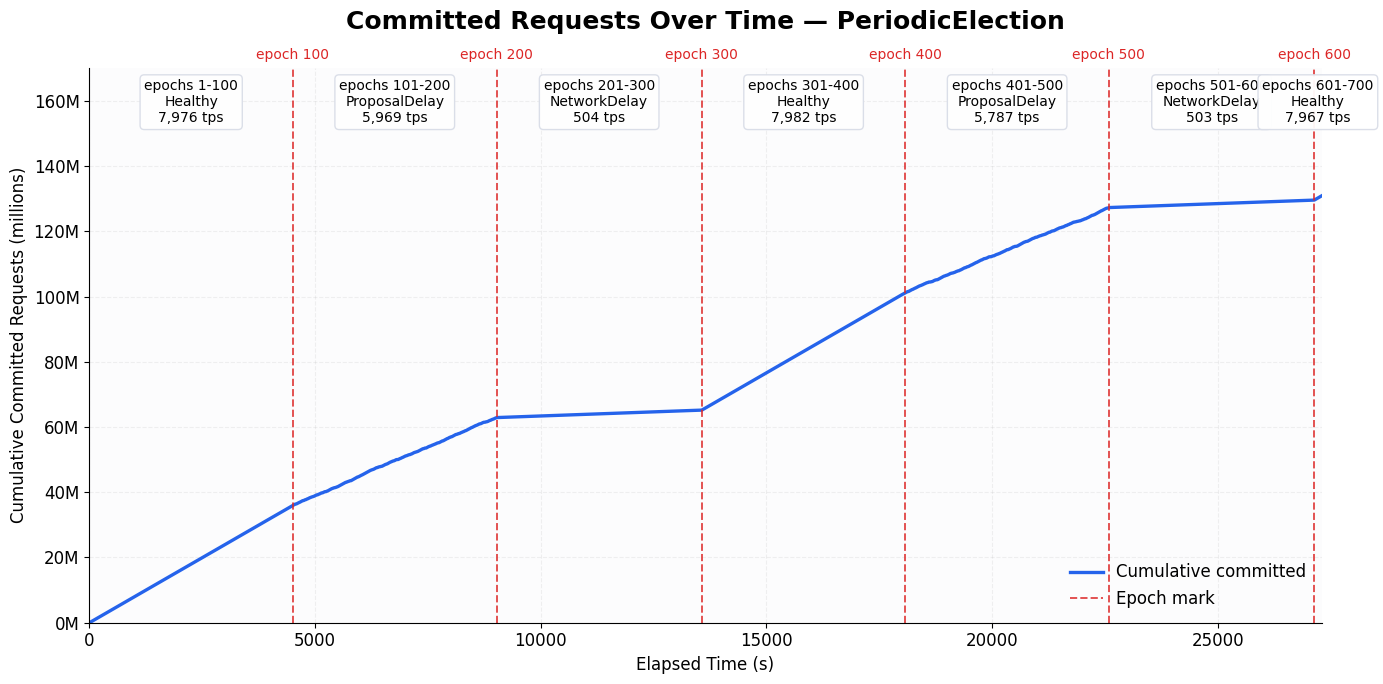

In [9]:
# Cumulative committed requests with epoch marks and per-scenario window average — PeriodicElection (periodicelection_20260922_014129)
# Epoch marks come from the "scenario switch gen=N" lines in node_1.log (UTC).
json_path = Path("results/periodicelection_20260922_014129/report.json")
assert json_path.exists(), f"Missing file: {json_path.resolve()}"
with json_path.open() as f:
    raw_periodicelection = json.load(f)
df_periodicelection = pd.DataFrame(raw_periodicelection).sort_values("elapsed_sec").reset_index(drop=True)

scenario_switches_periodicelection = [
    (100, "2026-09-22 02:56:46.689809"),
    (200, "2026-09-22 04:11:57.011982"),
    (300, "2026-09-22 05:27:45.705925"),
    (400, "2026-09-22 06:42:56.014182"),
    (500, "2026-09-22 07:58:06.318154"),
    (600, "2026-09-22 09:13:55.796109"),
]
scenario_names_periodicelection = ["Healthy", "ProposalDelay", "NetworkDelay", "Healthy", "ProposalDelay", "NetworkDelay", "Healthy"]

# report.json elapsed_sec = 0 at (first sample time - first elapsed_sec)
run_start_periodicelection = pd.Timestamp(df_periodicelection["timestamp_unix_nano"].iloc[0], unit="ns") - pd.Timedelta(seconds=df_periodicelection["elapsed_sec"].iloc[0])
epoch_marks_periodicelection = [(ep, (pd.Timestamp(ts) - run_start_periodicelection.tz_localize(None)).total_seconds()) for ep, ts in scenario_switches_periodicelection]

cum_df_periodicelection = df_periodicelection[df_periodicelection["committed_total"] > 0].drop_duplicates("elapsed_sec")
end_sec_periodicelection = float(cum_df_periodicelection["elapsed_sec"].iloc[-1])
edges_periodicelection = [0.0] + [t for _, t in epoch_marks_periodicelection] + [end_sec_periodicelection]
epoch_labels_periodicelection = [f"{a}-{b}" for a, b in zip([1] + [e + 1 for e, _ in epoch_marks_periodicelection], [e for e, _ in epoch_marks_periodicelection] + [700])]

def committed_at_periodicelection(t):
    return float(np.interp(t, cum_df_periodicelection["elapsed_sec"], cum_df_periodicelection["committed_total"]))

scenario_stats_periodicelection = []
for i, (t0, t1) in enumerate(zip(edges_periodicelection[:-1], edges_periodicelection[1:])):
    c0, c1 = committed_at_periodicelection(t0), committed_at_periodicelection(t1)
    scenario_stats_periodicelection.append(dict(epochs=epoch_labels_periodicelection[i], scenario=scenario_names_periodicelection[i], start=t0, end=t1,
                               committed=c1 - c0, avg_tps=(c1 - c0) / (t1 - t0)))
display(pd.DataFrame(scenario_stats_periodicelection).round(1))

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(cum_df_periodicelection["elapsed_sec"], cum_df_periodicelection["committed_total"], color="#2563EB", linewidth=2.4,
        label="Cumulative committed")

for i, (ep, t) in enumerate(epoch_marks_periodicelection):
    ax.axvline(t, color="#DC2626", linestyle="--", linewidth=1.4, alpha=0.8,
               label="Epoch mark" if i == 0 else None)
    ax.text(t, 1.01, f"epoch {ep}", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontsize=10, color="#DC2626")

for s in scenario_stats_periodicelection:
    mid = (s["start"] + s["end"]) / 2
    ax.annotate(
        f"epochs {s['epochs']}\n{s['scenario']}\n{s['avg_tps']:,.0f} tps",
        xy=(mid, 0.98), xycoords=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d9dde7", alpha=0.95),
    )

ax.set_title("Committed Requests Over Time — PeriodicElection", fontsize=18, weight="bold", pad=28)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests (millions)")
ax.set_xlim(0, end_sec_periodicelection)
ax.set_ylim(0, cum_df_periodicelection["committed_total"].max() * 1.3)  # headroom for the labels
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value / 1e6:g}M"))
ax.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.show()

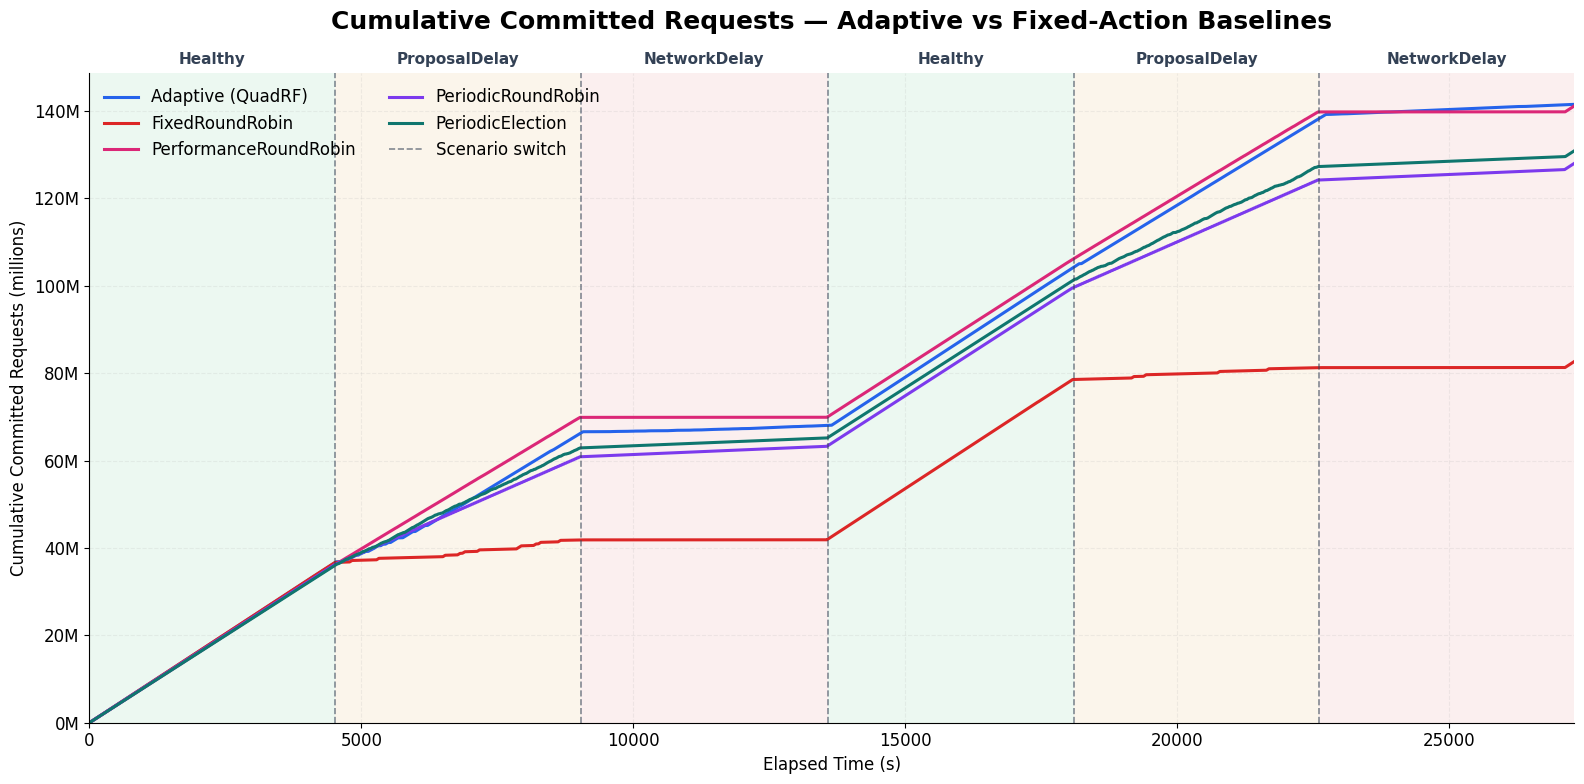

In [11]:
# All actions on one graph: adaptive (QuadRF) vs the four fixed-action baselines.
# Each run cycles Healthy -> ProposalDelay -> NetworkDelay -> Healthy -> ProposalDelay -> NetworkDelay,
# switching every 100 epochs (45s/epoch, so ~4500s/scenario nominally); real switch timestamps
# below come from the "scenario switch gen=N" lines in each run's node_1.log (UTC). Only the first
# six segments (through the 500-600 boundary) are shown.
combined_datasets = [
    dict(
        label="Adaptive (QuadRF)",
        json_path=Path("results/results/run2new_20260920_011708/report.json"),
        color="#2563EB",
        switch_ts=["2026-09-20 02:32:49.208910", "2026-09-20 03:48:30.282941", "2026-09-20 05:04:46.391492", "2026-09-20 06:20:27.785521", "2026-09-20 07:36:09.262274"],
    ),
    dict(
        label="FixedRoundRobin",
        json_path=Path("results/fixedrr_20260922_014036/report.json"),
        color="#DC2626",
        switch_ts=["2026-09-22 02:55:54.068521", "2026-09-22 04:11:04.307229", "2026-09-22 05:26:49.055385", "2026-09-22 06:41:59.511526", "2026-09-22 07:57:09.814760"],
    ),
    dict(
        label="PerformanceRoundRobin",
        json_path=Path("results/perfrr_20260922_014143/report.json"),
        color="#DB2777",
        switch_ts=["2026-09-22 02:57:01.140487", "2026-09-22 04:12:11.504616", "2026-09-22 05:27:59.168365", "2026-09-22 06:43:09.583775", "2026-09-22 07:58:19.934677"],
    ),
    dict(
        label="PeriodicRoundRobin",
        json_path=Path("results/periodicrr_20260922_014117/report.json"),
        color="#7C3AED",
        switch_ts=["2026-09-22 02:56:35.414048", "2026-09-22 04:11:45.775652", "2026-09-22 05:27:29.884487", "2026-09-22 06:42:40.203517", "2026-09-22 07:57:50.547298"],
    ),
    dict(
        label="PeriodicElection",
        json_path=Path("results/periodicelection_20260922_014129/report.json"),
        color="#0F766E",
        switch_ts=["2026-09-22 02:56:46.689809", "2026-09-22 04:11:57.011982", "2026-09-22 05:27:45.705925", "2026-09-22 06:42:56.014182", "2026-09-22 07:58:06.318154"],
    ),
]
scenario_names_combined = ["Healthy", "ProposalDelay", "NetworkDelay", "Healthy", "ProposalDelay", "NetworkDelay"]
scenario_bg_combined = {"Healthy": "#22C55E", "ProposalDelay": "#F59E0B", "NetworkDelay": "#EF4444"}

combined_frames = []
all_marks = []
for spec in combined_datasets:
    assert spec["json_path"].exists(), f"Missing file: {spec['json_path'].resolve()}"
    with spec["json_path"].open() as f:
        raw = json.load(f)
    frame = pd.DataFrame(raw).sort_values("elapsed_sec").reset_index(drop=True)
    run_start = pd.Timestamp(frame["timestamp_unix_nano"].iloc[0], unit="ns") - pd.Timedelta(seconds=frame["elapsed_sec"].iloc[0])
    marks_elapsed = [(pd.Timestamp(ts) - run_start.tz_localize(None)).total_seconds() for ts in spec["switch_ts"]]
    cum_df = frame[frame["committed_total"] > 0].drop_duplicates("elapsed_sec")
    combined_frames.append(dict(label=spec["label"], color=spec["color"], cum_df=cum_df, marks=marks_elapsed,
                                end_sec=float(cum_df["elapsed_sec"].iloc[-1])))
    all_marks.append(marks_elapsed)

# Marks land within ~15s of each other across runs (same 45s-epoch schedule); average them
# for one shared set of scenario boundaries to annotate against.
epoch_marks_combined = [sum(vals) / len(vals) for vals in zip(*all_marks)]
combined_end_sec = min(f["end_sec"] for f in combined_frames)
combined_edges = [0.0] + epoch_marks_combined + [combined_end_sec]

fig, ax = plt.subplots(figsize=(16, 8))

for name, (t0, t1) in zip(scenario_names_combined, zip(combined_edges[:-1], combined_edges[1:])):
    ax.axvspan(t0, t1, color=scenario_bg_combined[name], alpha=0.07, linewidth=0)

for frame in combined_frames:
    ax.plot(frame["cum_df"]["elapsed_sec"], frame["cum_df"]["committed_total"],
            color=frame["color"], linewidth=2.2, label=frame["label"])

for i, t in enumerate(epoch_marks_combined):
    ax.axvline(t, color="#334155", linestyle="--", linewidth=1.2, alpha=0.6,
               label="Scenario switch" if i == 0 else None)

for name, (t0, t1) in zip(scenario_names_combined, zip(combined_edges[:-1], combined_edges[1:])):
    mid = (t0 + t1) / 2
    ax.text(mid, 1.01, name, transform=ax.get_xaxis_transform(), ha="center", va="bottom",
            fontsize=11, weight="bold", color="#334155")

ax.set_title("Cumulative Committed Requests — Adaptive vs Fixed-Action Baselines", fontsize=18, weight="bold", pad=32)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests (millions)")
ax.set_xlim(0, combined_end_sec)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value / 1e6:g}M"))
ax.legend(loc="upper left", frameon=False, ncol=2)

plt.tight_layout()
plt.show()

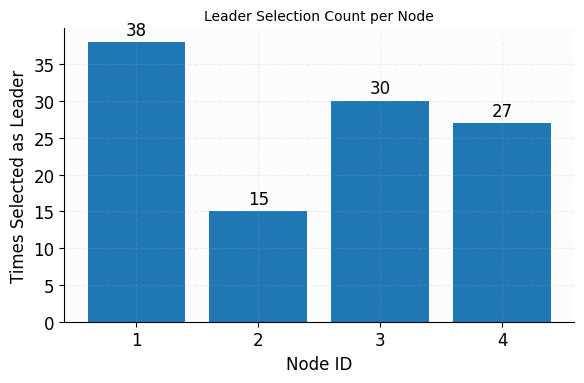

In [71]:
import matplotlib.pyplot as plt

leader_counts = {
    1: 38,
    2: 15,
    3: 30,
    4: 27,
}
# 1,42; 2,6; 3,28; 4,23

nodes = list(leader_counts.keys())
counts = list(leader_counts.values())

plt.figure(figsize=(6, 4))
plt.bar(nodes, counts)

plt.title("Leader Selection Count per Node", fontsize=10)
plt.xlabel("Node ID")
plt.ylabel("Times Selected as Leader")
plt.xticks(nodes)
plt.ylim(bottom=0)

for node, count in zip(nodes, counts):
    plt.text(node, count + 0.5, str(count), ha="center", va="bottom")

plt.tight_layout()
plt.show()


## Node Client Receive Rate

This section loads the node-side CSV written by `clientReceiveRateLogger` and summarizes receive TPS over time.


In [ ]:
# Change this to pick which node receive-rate CSV to plot.
receive_node_id = 1
receive_rate_csv_path = Path("logs") / f"node_{receive_node_id}_client_receive_rate.csv"
assert receive_rate_csv_path.exists(), f"Missing file: {receive_rate_csv_path.resolve()}"

receive_df = pd.read_csv(receive_rate_csv_path)
receive_df["timestamp"] = pd.to_datetime(receive_df["timestamp"])
receive_df = receive_df.sort_values("elapsed_sec").reset_index(drop=True)

# Trim idle samples after the node stops receiving new client transactions.
change_mask = receive_df["received_total"].ne(receive_df["received_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    receive_plot_df = receive_df.loc[:last_change_idx].copy()
else:
    receive_plot_df = receive_df.copy()

receive_plot_df["window_tps_smooth"] = (
    receive_plot_df["window_tps"].rolling(window=5, min_periods=1).mean()
)

active_receive_df = receive_plot_df[receive_plot_df["received_delta"] > 0].copy()
if active_receive_df.empty:
    active_receive_df = receive_plot_df.copy()

receive_summary = {
    "samples": int(len(receive_df)),
    "plot_samples": int(len(receive_plot_df)),
    "active_samples": int(len(active_receive_df)),
    "final_received": int(receive_plot_df["received_total"].iloc[-1]),
    "elapsed_sec": float(receive_plot_df["elapsed_sec"].iloc[-1]),
    "mean_window_tps_active": float(active_receive_df["window_tps"].mean()),
    "median_window_tps_active": float(active_receive_df["window_tps"].median()),
    "p95_window_tps_active": float(active_receive_df["window_tps"].quantile(0.95)),
    "peak_window_tps": float(receive_plot_df["window_tps"].max()),
    "peak_smoothed_tps": float(receive_plot_df["window_tps_smooth"].max()),
    "final_average_tps": float(receive_plot_df["average_tps"].iloc[-1]),
}

display(pd.Series(receive_summary))
display(receive_plot_df.head())


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

receive_color = "#2563EB"
receive_smooth_color = "#DC2626"
total_color = "#475569"

ax1.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["window_tps"],
    color=receive_color,
    linewidth=1.6,
    alpha=0.30,
    label="Window receive TPS",
)
ax1.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["window_tps_smooth"],
    color=receive_smooth_color,
    linewidth=3.0,
    label="Smoothed receive TPS (5-sample rolling mean)",
)

peak_idx = receive_plot_df["window_tps_smooth"].idxmax()
peak_x = receive_plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = receive_plot_df.loc[peak_idx, "window_tps_smooth"]
ax1.scatter([peak_x], [peak_y], color=receive_smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed receive TPS\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=receive_smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=receive_smooth_color, alpha=0.9),
)

ax1.set_title(f"Node {receive_node_id} Client Receive Rate Over Time", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("Receive TPS")
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(
    receive_plot_df["elapsed_sec"],
    receive_plot_df["received_total"],
    color=total_color,
    linewidth=2.0,
    alpha=0.65,
    label="Total received",
)
ax2.set_ylabel("Total Received Transactions")
ax2.grid(False)

summary_text = (
    f"Elapsed: {receive_summary['elapsed_sec']:.2f}s\n"
    f"Final received: {receive_summary['final_received']:,}\n"
    f"Mean active TPS: {receive_summary['mean_window_tps_active']:.1f}\n"
    f"Median active TPS: {receive_summary['median_window_tps_active']:.1f}\n"
    f"P95 active TPS: {receive_summary['p95_window_tps_active']:.1f}\n"
    f"Final avg TPS: {receive_summary['final_average_tps']:.1f}"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
receive_output_path = Path(f"node_{receive_node_id}_client_receive_rate.png")
fig.savefig(receive_output_path, dpi=220, bbox_inches="tight")
receive_output_path.resolve()


## Leader PrePrepare Process Rate

This section loads the leader-side CSV written by `leaderPreprepareRateLogger` and summarizes locally processed PrePrepares over time.


In [ ]:
# Change this to pick which leader PrePrepare process-rate CSV to plot.
preprepare_node_id = 1
preprepare_rate_csv_path = Path("logs") / f"node_{preprepare_node_id}_leader_preprepare_rate.csv"
assert preprepare_rate_csv_path.exists(), f"Missing file: {preprepare_rate_csv_path.resolve()}"

preprepare_df = pd.read_csv(preprepare_rate_csv_path)
preprepare_df["timestamp"] = pd.to_datetime(preprepare_df["timestamp"])
preprepare_df = preprepare_df.sort_values("elapsed_sec").reset_index(drop=True)

# Trim idle samples after the leader stops processing new PrePrepares.
change_mask = preprepare_df["preprepare_total"].ne(preprepare_df["preprepare_total"].shift(fill_value=-1))
if change_mask.any():
    last_change_idx = change_mask[change_mask].index[-1]
    preprepare_plot_df = preprepare_df.loc[:last_change_idx].copy()
else:
    preprepare_plot_df = preprepare_df.copy()

preprepare_plot_df["window_preprepare_per_sec_smooth"] = (
    preprepare_plot_df["window_preprepare_per_sec"].rolling(window=5, min_periods=1).mean()
)

active_preprepare_df = preprepare_plot_df[preprepare_plot_df["preprepare_delta"] > 0].copy()
if active_preprepare_df.empty:
    active_preprepare_df = preprepare_plot_df.copy()

preprepare_summary = {
    "samples": int(len(preprepare_df)),
    "plot_samples": int(len(preprepare_plot_df)),
    "active_samples": int(len(active_preprepare_df)),
    "final_preprepares": int(preprepare_plot_df["preprepare_total"].iloc[-1]),
    "elapsed_sec": float(preprepare_plot_df["elapsed_sec"].iloc[-1]),
    "mean_window_preprepare_per_sec_active": float(active_preprepare_df["window_preprepare_per_sec"].mean()),
    "median_window_preprepare_per_sec_active": float(active_preprepare_df["window_preprepare_per_sec"].median()),
    "p95_window_preprepare_per_sec_active": float(active_preprepare_df["window_preprepare_per_sec"].quantile(0.95)),
    "peak_window_preprepare_per_sec": float(preprepare_plot_df["window_preprepare_per_sec"].max()),
    "peak_smoothed_preprepare_per_sec": float(preprepare_plot_df["window_preprepare_per_sec_smooth"].max()),
    "final_average_preprepare_per_sec": float(preprepare_plot_df["average_preprepare_per_sec"].iloc[-1]),
}

display(pd.Series(preprepare_summary))
display(preprepare_plot_df.head())


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 7))

preprepare_color = "#0F766E"
preprepare_smooth_color = "#EA580C"
total_color = "#475569"

ax1.plot(
    preprepare_plot_df["elapsed_sec"],
    preprepare_plot_df["window_preprepare_per_sec"],
    color=preprepare_color,
    linewidth=1.6,
    alpha=0.30,
    label="Window PrePrepare/sec",
)
ax1.plot(
    preprepare_plot_df["elapsed_sec"],
    preprepare_plot_df["window_preprepare_per_sec_smooth"],
    color=preprepare_smooth_color,
    linewidth=3.0,
    label="Smoothed PrePrepare/sec (5-sample rolling mean)",
)

peak_idx = preprepare_plot_df["window_preprepare_per_sec_smooth"].idxmax()
peak_x = preprepare_plot_df.loc[peak_idx, "elapsed_sec"]
peak_y = preprepare_plot_df.loc[peak_idx, "window_preprepare_per_sec_smooth"]
ax1.scatter([peak_x], [peak_y], color=preprepare_smooth_color, s=70, zorder=5)
ax1.annotate(
    f"Peak smoothed PrePrepare/sec\n{peak_y:.1f}",
    xy=(peak_x, peak_y),
    xytext=(12, 14),
    textcoords="offset points",
    fontsize=11,
    color=preprepare_smooth_color,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=preprepare_smooth_color, alpha=0.9),
)

ax1.set_title(f"Node {preprepare_node_id} Leader PrePrepare Process Rate Over Time", fontsize=18, weight="bold", pad=16)
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("PrePrepare/sec")
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(
    preprepare_plot_df["elapsed_sec"],
    preprepare_plot_df["preprepare_total"],
    color=total_color,
    linewidth=2.0,
    alpha=0.65,
    label="Total PrePrepares",
)
ax2.set_ylabel("Total Leader PrePrepares Processed")
ax2.grid(False)

summary_text = (
    f"Elapsed: {preprepare_summary['elapsed_sec']:.2f}s\n"
    f"Final PrePrepares: {preprepare_summary['final_preprepares']:,}\n"
    f"Mean active: {preprepare_summary['mean_window_preprepare_per_sec_active']:.1f}/s\n"
    f"Median active: {preprepare_summary['median_window_preprepare_per_sec_active']:.1f}/s\n"
    f"P95 active: {preprepare_summary['p95_window_preprepare_per_sec_active']:.1f}/s\n"
    f"Final avg: {preprepare_summary['final_average_preprepare_per_sec']:.1f}/s"
)
ax1.text(
    0.015,
    0.97,
    summary_text,
    transform=ax1.transAxes,
    va="top",
    ha="left",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()


In [ ]:
preprepare_output_path = Path(f"node_{preprepare_node_id}_leader_preprepare_rate.png")
fig.savefig(preprepare_output_path, dpi=220, bbox_inches="tight")
preprepare_output_path.resolve()


## Cumulative Committed Requests Over Time

This section plots the total number of committed client requests against elapsed experiment time using the complete `logs/ch.json` series.


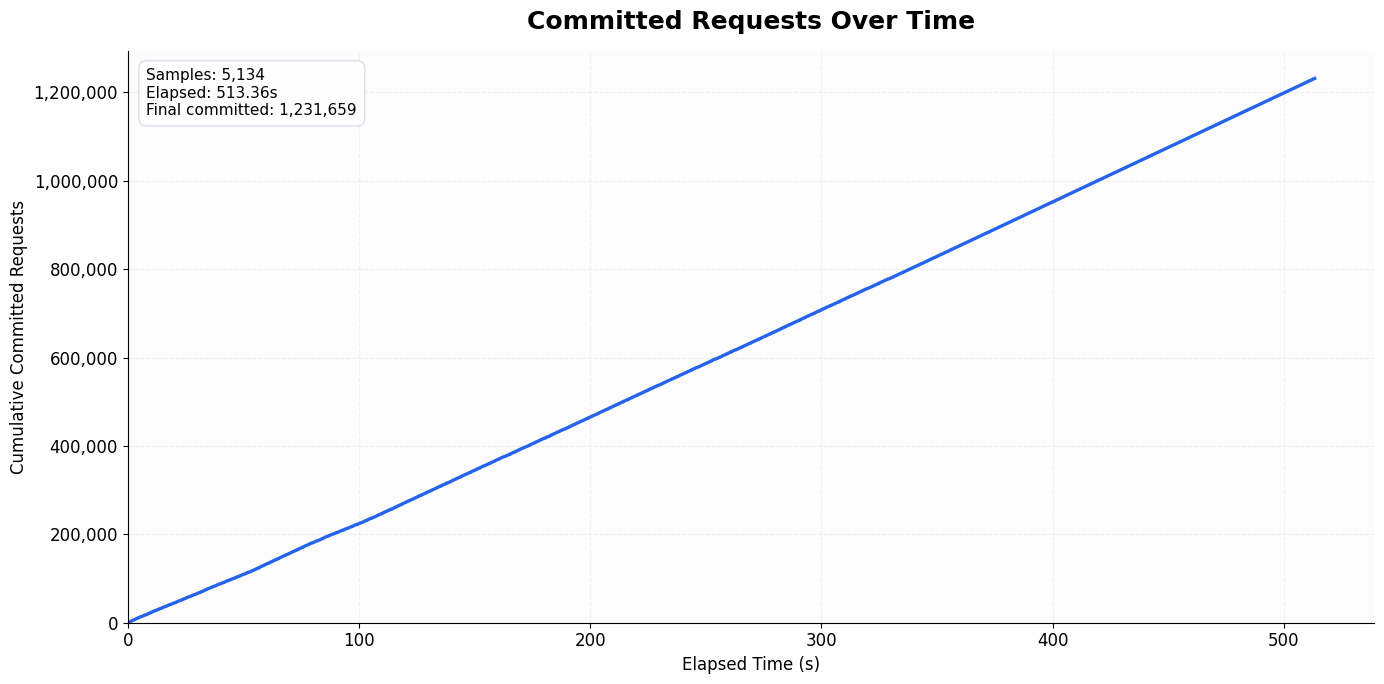

In [32]:
committed_json_path = Path("logs/ch.json")
assert committed_json_path.exists(), f"Missing file: {committed_json_path.resolve()}"

with committed_json_path.open() as f:
    committed_raw = json.load(f)

committed_df = pd.DataFrame(committed_raw)
required_columns = {"elapsed_sec", "committed_total"}
missing_columns = required_columns - set(committed_df.columns)
assert not missing_columns, f"Missing columns: {sorted(missing_columns)}"

committed_df = (
    committed_df[["elapsed_sec", "committed_total"]]
    .dropna()
    .sort_values("elapsed_sec")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(
    committed_df["elapsed_sec"],
    committed_df["committed_total"],
    color="#2563EB",
    linewidth=2.4,
)
ax.set_title("Committed Requests Over Time", fontsize=18, weight="bold", pad=16)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

final_elapsed = committed_df["elapsed_sec"].iloc[-1]
final_committed = int(committed_df["committed_total"].iloc[-1])
ax.text(
    0.015,
    0.97,
    f"Samples: {len(committed_df):,}\n"
    f"Elapsed: {final_elapsed:.2f}s\n"
    f"Final committed: {final_committed:,}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)

plt.tight_layout()
plt.show()


## Fixed vs Adaptive: Cumulative Commits Through 800 Seconds

This comparison uses experiment-relative elapsed time and the same 800-second observation window. `logs/ch.json` is the fixed-only run, while `fullrun_adaptive_100mssampling/ch.json` is the adaptive run. Both files use approximately 100 ms sampling.


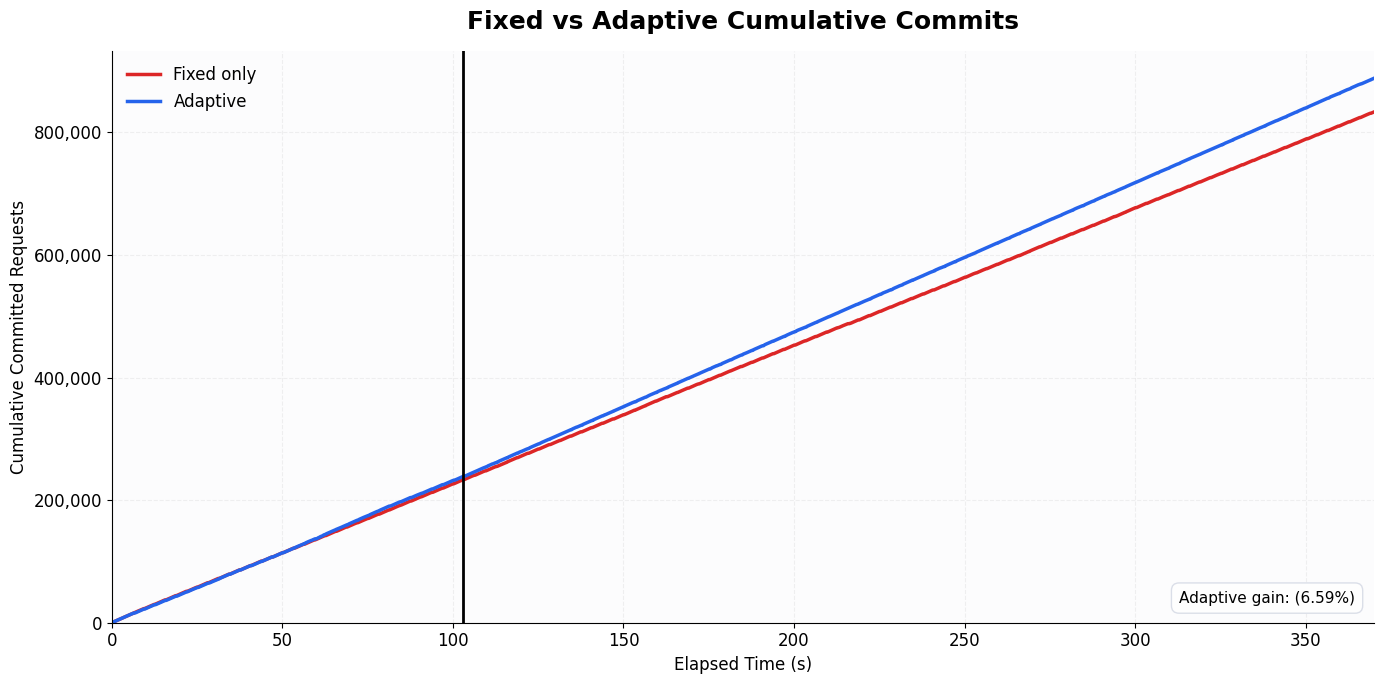

fixed_committed_by_800s       833054.00000
adaptive_committed_by_800s    887986.00000
adaptive_commit_gain           54932.00000
adaptive_gain_percent              6.59405
dtype: float64

In [7]:
comparison_cutoff_sec = 370
comparison_paths = {
    "Fixed only": Path("fixed_full/ch.json"),
    "Adaptive": Path("adaptive/ch.json"),
}
comparison_colors = {
    "Fixed only": "#DC2626",
    "Adaptive": "#2563EB",
}

comparison_frames = {}
for label, path in comparison_paths.items():
    assert path.exists(), f"Missing file: {path.resolve()}"
    with path.open() as f:
        records = json.load(f)

    frame = pd.DataFrame(records)
    required_columns = {"elapsed_sec", "committed_total"}
    missing_columns = required_columns - set(frame.columns)
    assert not missing_columns, f"{path} is missing columns: {sorted(missing_columns)}"

    frame = (
        frame[["elapsed_sec", "committed_total"]]
        .dropna()
        .sort_values("elapsed_sec")
        .drop_duplicates("elapsed_sec", keep="last")
    )
    frame = frame[frame["elapsed_sec"] <= comparison_cutoff_sec].copy()
    assert not frame.empty, f"{path} has no samples through {comparison_cutoff_sec}s"
    comparison_frames[label] = frame

fig, ax = plt.subplots(figsize=(14, 7))
for label, frame in comparison_frames.items():
    ax.plot(
        frame["elapsed_sec"],
        frame["committed_total"],
        color=comparison_colors[label],
        linewidth=2.5,
        label=label,
    )

fixed_committed_800 = int(comparison_frames["Fixed only"]["committed_total"].iloc[-1])
adaptive_committed_800 = int(comparison_frames["Adaptive"]["committed_total"].iloc[-1])
commit_gain = adaptive_committed_800 - fixed_committed_800
commit_gain_pct = 100.0 * commit_gain / fixed_committed_800

ax.set_title("Fixed vs Adaptive Cumulative Commits", fontsize=18, weight="bold", pad=16)
ax.set_xlabel("Elapsed Time (s)")
ax.set_ylabel("Cumulative Committed Requests")
ax.set_xlim(0, comparison_cutoff_sec)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.legend(loc="upper left", frameon=False)
ax.text(
    0.985,
    0.03,
    # f"At ~800s\n"
    # f"Fixed: {fixed_committed_800:,}\n"
    # f"Adaptive: {adaptive_committed_800:,}\n"
    f"Adaptive gain: ({commit_gain_pct:.2f}%)",
    transform=ax.transAxes,
    va="bottom",
    ha="right",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#d9dde7", alpha=0.95),
)
ax.axvline(
    x=103,
    color="black",
    linewidth=2,
    linestyle="-",
    label="108s",
)
plt.tight_layout()
plt.show()

pd.Series({
    "fixed_committed_by_800s": fixed_committed_800,
    "adaptive_committed_by_800s": adaptive_committed_800,
    "adaptive_commit_gain": commit_gain,
    "adaptive_gain_percent": commit_gain_pct,
})


In [90]:
tput = 180
num = 0
while tput < 200:
    tput = tput*1.01
    num += 1
print(num)


11
